In [ ]:
# Install required libraries
!pip install imbalanced-learn
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model saving
import joblib
from sklearn.preprocessing import LabelEncoder

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
train_df = pd.read_csv('/content/drive/MyDrive/fraudTrain.csv')
test_df = pd.read_csv('/content/drive/MyDrive/fraudTest.csv')

In [70]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [24]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [25]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (1296675, 23)
Test Shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [26]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [27]:
train_df["is_fraud"].value_counts()

,count
is_fraud,
0,1289169
1,7506


In [28]:
train_df["is_fraud"].value_counts(normalize=True)*100

,proportion
is_fraud,
0,99.421135
1,0.578865


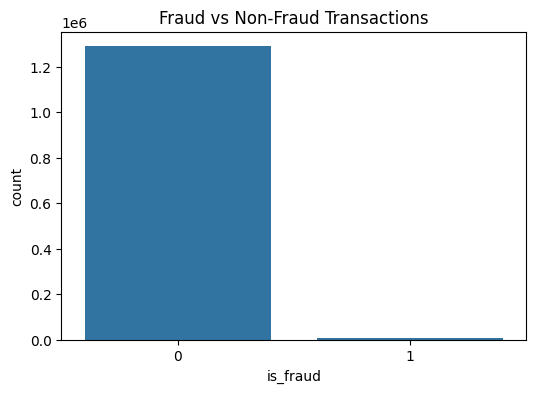

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=train_df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

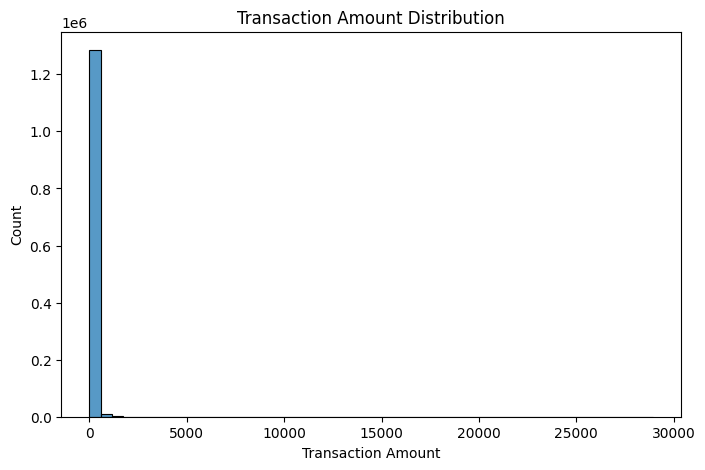

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(train_df["amt"], bins=50)

plt.title("Transaction Amount Distribution")

plt.xlabel("Transaction Amount")

plt.show()

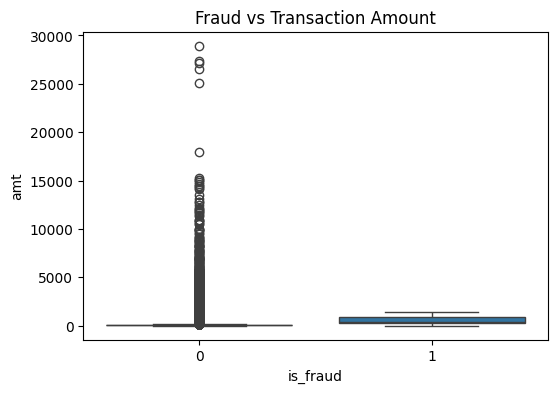

In [31]:
plt.figure(figsize=(6,4))

sns.boxplot(x="is_fraud", y="amt", data=train_df)

plt.title("Fraud vs Transaction Amount")

plt.show()

In [32]:
train_df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [71]:
drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "first",
    "last",
    "street",
    "city",
    "state",
    "zip",
    "dob",
    "trans_num"
]

train_df = train_df.drop(columns=drop_cols, errors="ignore")
test_df = test_df.drop(columns=drop_cols, errors="ignore")

In [63]:
print("Train columns:")
print(train_df.columns)

Train columns:
Index(['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop',
       'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'distance',
       'hour', 'amt_log'],
      dtype='object')


In [64]:
print("Test columns:")
print(test_df.columns)

Test columns:
Index(['merchant', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop',
       'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'distance',
       'hour', 'amt_log'],
      dtype='object')


In [72]:
train_df["distance"] = np.sqrt(
    (train_df["lat"] - train_df["merch_lat"])**2 +
    (train_df["long"] - train_df["merch_long"])**2
)

test_df["distance"] = np.sqrt(
    (test_df["lat"] - test_df["merch_lat"])**2 +
    (test_df["long"] - test_df["merch_long"])**2
)

train_df["hour"] = (train_df["unix_time"] // 3600) % 24
test_df["hour"] = (test_df["unix_time"] // 3600) % 24

In [73]:
train_df["amt_log"] = np.log1p(train_df["amt"])
test_df["amt_log"] = np.log1p(test_df["amt"])

In [74]:
train_df["tx_time_diff"] = train_df.groupby("cc_num")["unix_time"].diff().fillna(0)
test_df["tx_time_diff"] = test_df.groupby("cc_num")["unix_time"].diff().fillna(0)

In [75]:
train_avg_amt = train_df.groupby("cc_num")["amt"].transform("mean")
test_avg_amt = test_df.groupby("cc_num")["amt"].transform("mean")

train_df["amt_deviation"] = train_df["amt"] / (train_avg_amt + 1)
test_df["amt_deviation"] = test_df["amt"] / (test_avg_amt + 1)

In [76]:
cat_cols = ["merchant","category","gender","job"]

for col in cat_cols:
    train_df[col] = train_df[col].astype("category").cat.codes
    test_df[col] = test_df[col].astype("category").cat.codes

In [77]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

In [78]:
X_train.dtypes

,0
cc_num,int64
merchant,int16
category,int8
amt,float64
gender,int8
lat,float64
long,float64
city_pop,int64
job,int16
unix_time,int64


In [79]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=10,
    scale_pos_weight=170,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [80]:
pred_prob = xgb.predict_proba(X_test)[:,1]

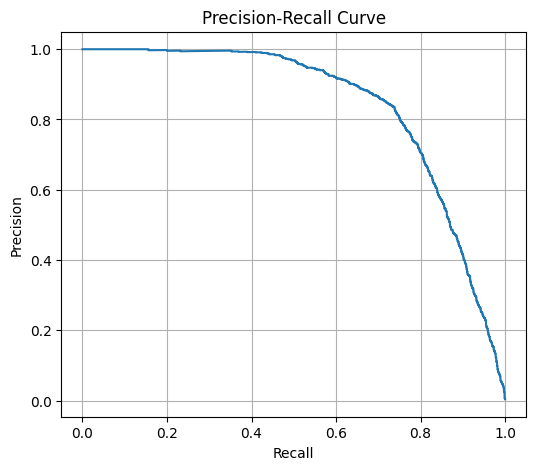

In [81]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [82]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best Precision:", precision[best_index])
print("Best Recall:", recall[best_index])
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.78280497
Best Precision: 0.8357972544878564
Best Recall: 0.737995337995338
Best F1 Score: 0.7838573903933721


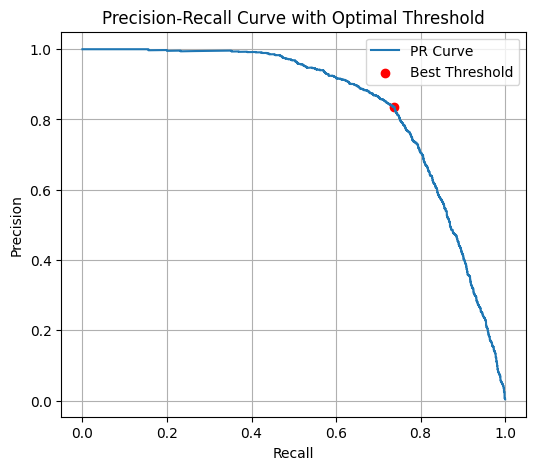

In [86]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(recall[best_index], precision[best_index], color="red", label="Best Threshold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
pred = (pred_prob > best_threshold).astype(int)

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.84      0.74      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.92      0.87      0.89    555719
weighted avg       1.00      1.00      1.00    555719



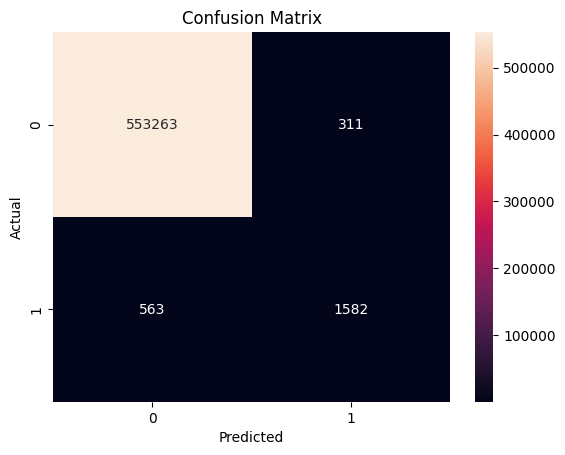

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()